## **Inspección visual de un producto**

### Ficha PEAS

| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Matriz 5×5 de NumPy (0 = normal, 1 = defectuoso) |
| **Entorno (E)** | Línea de producción donde pasan los productos frente a una cámara |
| **Acciones (A)** | Aprobar, enviar a revisión manual, rechazar |
| **Objetivo** | Evitar que lleguen productos defectuosos sin descartar productos buenos por error |
| **Medida de desempeño (P)** | Defectos detectados correctamente, productos buenos rechazados por error |

### Justificación de las reglas

Si no hay ningún píxel defectuoso, se aprueba directamente porque el producto está en buen estado. De 1 a 3 píxeles defectuosos se manda a revisión manual porque podría ser un defecto menor o un error de la cámara, y conviene que una persona lo confirme antes de decidir. Con más de 3 píxeles defectuosos se rechaza directamente, porque ya es una cantidad de defectos que indica un problema real en el producto y no vale la pena revisarlo manualmente.

In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    """
    defectos = np.sum(imagen == 1)
    if defectos == 0:
        return "aprobar", "no se detectaron pixeles defectuosos"
    elif defectos <= 3:
        return "revision manual", f"se detectaron {defectos} pixeles defectuosos"
    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos"

### Simulación y pruebas

          0 defectos -> aprobar (no se detectaron pixeles defectuosos)
          2 defectos -> revision manual (se detectaron 2 pixeles defectuosos)
  3 defectos (borde) -> revision manual (se detectaron 3 pixeles defectuosos)
          4 defectos -> rechazar (se detectaron 4 pixeles defectuosos)


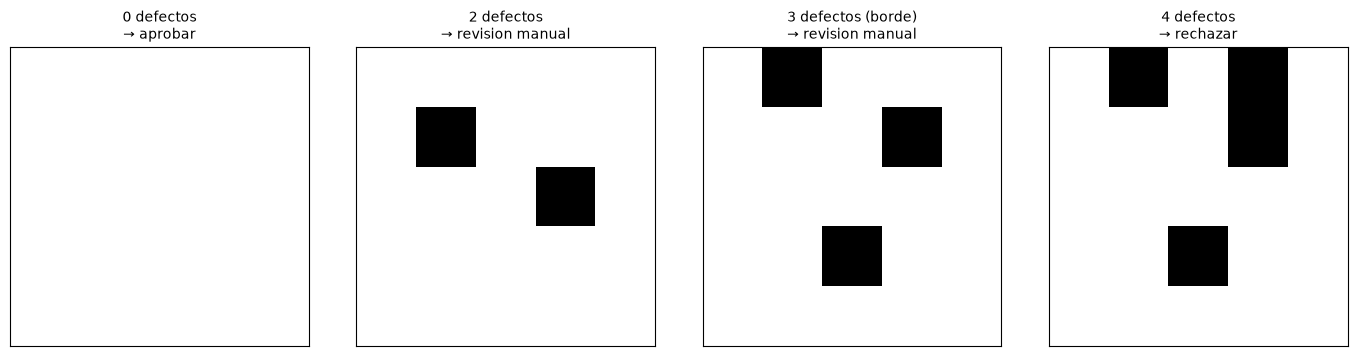

In [2]:
import numpy as np
import matplotlib.pyplot as plt

imagen_0 = np.zeros((5, 5), dtype=int)

imagen_2 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

imagen_3 = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
])

imagen_4 = np.array([
    [0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
])

imagenes = {
    "0 defectos": imagen_0,
    "2 defectos": imagen_2,
    "3 defectos (borde)": imagen_3,
    "4 defectos": imagen_4,
}

fig, axes = plt.subplots(1, len(imagenes), figsize=(14, 3.5))
for ax, (nombre, img) in zip(axes, imagenes.items()):
    accion, motivo = agente_inspeccion(img)
    ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"{nombre}\n→ {accion}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    print(f"{nombre:>20} -> {accion} ({motivo})")

plt.tight_layout()
plt.show()